In [49]:
import numpy as np
import tensorflow as tf
##PACKAGES

In [50]:
from tensorflow import keras
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras import Sequential

In [51]:

(x_train,y_train),(x_test,y_test)=tf.keras.datasets.mnist.load_data()
##LOADING THE NEEDED DATA 


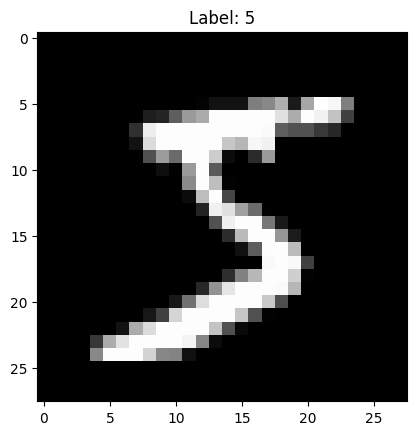

In [52]:
##visulize some of the data
import matplotlib.pyplot as plt
plt.imshow(x_train[0], cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.show()

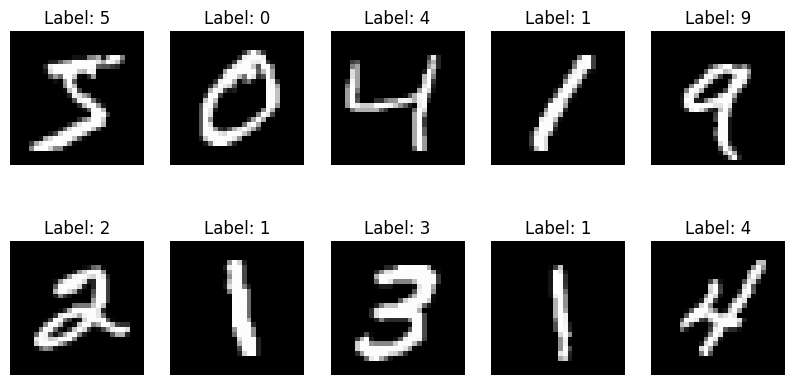

In [53]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i], cmap="gray")
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis("off")

plt.show()

In [54]:
#RESHAPING
x_train=x_train.reshape(-1, 784)/255.0
x_test=x_test.reshape(-1, 784)/255.0


In [55]:
#making the model
model=Sequential([
    Input(shape=(784,)),
    Dense(units=25,activation='relu'),#first layer
    Dense(units=15,activation='relu'),#second layer
    Dense(units=10,activation='linear'),#final layer
])
    

In [56]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
)

In [57]:
print(type(x_train), x_train.shape, x_train.dtype)
print(type(y_train), y_train.shape, y_train.dtype)


<class 'numpy.ndarray'> (60000, 784) float64
<class 'numpy.ndarray'> (60000,) uint8


In [58]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 25)             │        19,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 15)             │           390 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           160 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,175 (78.81 KB)

 Trainable params: 20,175 (78.81 KB)

 Non-trainable params: 0 (0.00 B)

In [59]:
model.fit(x_train,y_train,epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.4062
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.2011
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1658
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1453
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1312
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1180
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1097
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1039
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0977
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0914


In [60]:
#testing 
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1454


0.1454227715730667

In [61]:
##still testing
logits = model.predict(x_test)
predictions = np.argmax(logits, axis=1)
accuracy = np.mean(predictions == y_test)
print("test accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
test accuracy: 0.9585


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


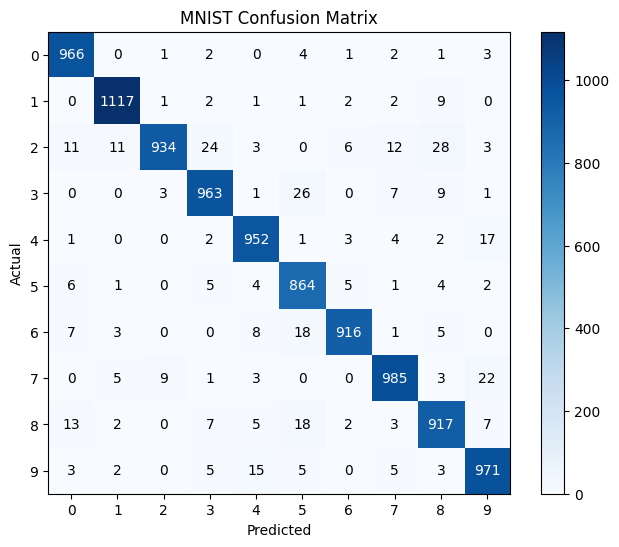

In [63]:
from sklearn.metrics import confusion_matrix
logits = model.predict(x_test)
predictions = np.argmax(logits, axis=1)

cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(8,6))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xticks(range(10)); plt.yticks(range(10))
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('MNIST Confusion Matrix')
# annotate counts
for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i,j], ha='center', va='center',
                 color='white' if cm[i,j] > 500 else 'black')
plt.show()



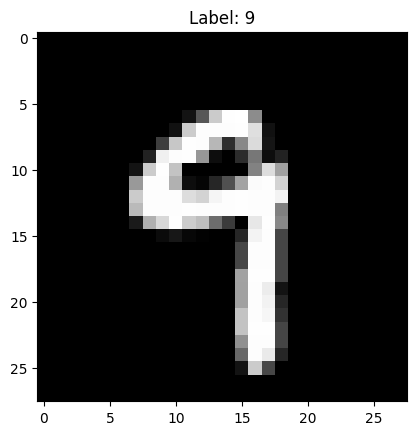

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
[[ -8.946033    -0.9862625   -9.83169     -1.2451272    4.282012
   -0.5723614  -13.256148     0.42664874  -0.3955491    9.99573   ]]
THE PICTURE IS: 9


In [71]:
index=108
image=x_test[index]
plt.imshow(image.reshape(28,28), cmap="gray")
plt.title(f"Label: {y_test[index]}")
plt.show()
predicted=model.predict(image.reshape(1,784))
print(predicted)
digit = np.argmax(predicted)
print("THE PICTURE IS:",digit)

In [80]:
#for softmax 
predict=tf.nn.softmax(predicted)
print(predict)
theone=np.argmax(predict)
print(theone)

tf.Tensor(
[[5.9183165e-09 1.6946597e-05 2.4409708e-09 1.3081533e-05 3.2890076e-03
  2.5635247e-05 7.9494800e-11 6.9614878e-05 3.0593284e-05 9.9655509e-01]], shape=(1, 10), dtype=float32)
9
